# MAX Auxetic ML V5 — Restricted-Tail + Physics-Validated High-Accuracy Framework

### هدف
این نسخه بر اساس نتایج V4 ساخته شده است و دو سؤال را جدا می‌کند:

1. **آیا حذف ناحیهٔ بسیار شدید `ν_min <= -1` باعث افزایش قابل توجه دقت عددی می‌شود؟**
2. **آیا مقادیر شدید واقعاً از تانسور الاستیک و محاسبهٔ جهت‌دار سازگار با VASPKIT به‌دست آمده‌اند؟**

سه سناریو به صورت جداگانه گزارش می‌شوند:

- **FULL:** تمام 547 مادهٔ پایدار.
- **RESTRICTED:** فقط `ν_min > -1`.
- **MODERATE:** فقط `ν_min > -0.5`.

> **نکتهٔ علمی:** سناریوی Restricted یک تحلیل حساسیت/مدل دامنه‌محدود است و نباید جایگزین نتیجهٔ Full شود مگر اینکه برای cutoff توجیه فیزیکی یا عددی مستقل پیدا شود.

### تغییرات مهم نسبت به V4
- ارزیابی جداگانهٔ Full / Restricted / Moderate.
- Yeo–Johnson و loss مقاوم به outlier.
- دو مرحله‌ای Auxetic/Non-auxetic.
- GroupKFold بر اساس عنصر M برای OOD.
- Ensemble فقط درون هر سناریو.
- **اعتبارسنجی مستقیم `C_ij -> ν_min` در برابر مقدار VASPKIT** قبل از استفاده از مسیر elastic-intermediate.
- گزارش هدف «`R² > 0.98`» به عنوان **آستانهٔ آزمایشی**، نه نتیجهٔ از پیش تضمین‌شده.

In [45]:
# ============================================================
# 0. Install / imports
# ============================================================
!pip install -q xgboost lightgbm catboost matminer pymatgen scikit-learn scipy

import re, json, os, sys, warnings, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    explained_variance_score, precision_recall_fscore_support,
    accuracy_score, roc_auc_score, average_precision_score,
    confusion_matrix
)
from sklearn.ensemble import (
    ExtraTreesRegressor, RandomForestRegressor,
    GradientBoostingRegressor, RandomForestClassifier,
    GradientBoostingClassifier, StackingRegressor
)
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

RANDOM_STATE = 42
N_JOBS = 2

# Kaggle first, local fallback second
CANDIDATE_DIRS = [
    "/kaggle/input/datasets/metisa81/elastic-properties",
    "/mnt/data"
]
DATA_DIR = next((p for p in CANDIDATE_DIRS if os.path.exists(os.path.join(p, "vaspkit_output.json"))), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not find vaspkit_output.json")

OUT_DIR = "/kaggle/working" if os.path.exists("/kaggle") else "/mnt/data"
os.makedirs(OUT_DIR, exist_ok=True)

print("✓ DATA_DIR:", DATA_DIR)
print("✓ OUT_DIR:", OUT_DIR)
print("✓ Python:", sys.version.split()[0])

✓ DATA_DIR: /kaggle/input/datasets/metisa81/elastic-properties
✓ OUT_DIR: /kaggle/working
✓ Python: 3.12.13


## 1. بارگذاری VASPKIT و ساخت دیتاست شیمیایی

ساختارهای POSCAR در این نسخه برای ویژگی هندسی وارد مدل نمی‌شوند، چون در پروژه فعلی template مشترک/غیرRelaxed دارند. هدف این notebook بررسی دقیق composition-based screening و مسیر elastic-intermediate است.

In [46]:
def parse_formula(name):
    # Accept names such as Ti2AlC / Ti2AlN while using the material key as formula.
    tokens = re.findall(r'[A-Z][a-z]?', name)
    if len(tokens) != 3:
        raise ValueError(f"Unexpected MAX formula: {name} -> {tokens}")
    return tokens

with open(os.path.join(DATA_DIR, "vaspkit_output.json"), "r") as f:
    vk = json.load(f)
ptable = pd.read_csv(os.path.join(DATA_DIR, "ptable2.csv")).set_index("symbol")

ELEMENT_COLS = [
    "atomic_number","atomic_radius","covalent_radius_cordero",
    "atomic_weight","density","melting_point","boiling_point",
    "en_pauling","electron_affinity","ionization_energy",
    "valance_main","group_id","period","dipole_polarizability",
    "atomic_volume","vdw_radius"
]

rows = []
for name, d in tqdm(vk.items(), desc="Building dataset"):
    try:
        stable = d.get("Additional_Properties", {}).get("Mechanical_Stability") == "Stable"
        aniso = d.get("Anisotropic_Mechanical_Properties", {}).get("Poisson's_Ratio_v")
        if not stable or not isinstance(aniso, dict) or "Min" not in aniso:
            continue
        m, a, x = parse_formula(name)
        if any(e not in ptable.index for e in [m,a,x]):
            continue

        r = {"material": name, "M": m, "A": a, "X": x}
        for site, el in [("M",m),("A",a),("X",x)]:
            for c in ELEMENT_COLS:
                r[f"{site}_{c}"] = float(ptable.loc[el,c])

        r["en_diff_MX"] = r["M_en_pauling"] - r["X_en_pauling"]
        r["en_diff_MA"] = r["M_en_pauling"] - r["A_en_pauling"]
        r["en_diff_AX"] = r["A_en_pauling"] - r["X_en_pauling"]
        r["radius_ratio_AX"] = r["A_covalent_radius_cordero"] / r["X_covalent_radius_cordero"]
        r["radius_ratio_MX"] = r["M_covalent_radius_cordero"] / r["X_covalent_radius_cordero"]
        r["radius_ratio_MA"] = r["M_covalent_radius_cordero"] / r["A_covalent_radius_cordero"]
        r["M_enpauling_x_Mgroup"] = r["M_en_pauling"] * r["M_group_id"]
        r["M_ionize_x_A_valance"] = r["M_ionization_energy"] * r["A_valance_main"]
        r["endiffMX_x_radiusratio"] = r["en_diff_MX"] * r["radius_ratio_AX"]
        r["Mgroup_x_Agroup"] = r["M_group_id"] * r["A_group_id"]
        r["Menpauling_x_Aenpauling"] = r["M_en_pauling"] * r["A_en_pauling"]
        r["VEC"] = (2*r["M_group_id"] + r["A_valance_main"] + r["X_valance_main"]) / 4
        r["VEC_x_endiffMX"] = r["VEC"] * r["en_diff_MX"]
        r["nu_min"] = float(aniso["Min"])
        r["nu_max"] = float(aniso.get("Max", np.nan))

        # Elastic tensor if available
        c = d.get("Elastic_Tensor_Voigt", {})
        for k in ["C11","C12","C13","C33","C44","C66"]:
            r[k] = float(c[k]) if k in c else np.nan
        rows.append(r)
    except Exception:
        continue

df = pd.DataFrame(rows).set_index("material")
CHEM_FEATURES = [
    c for c in df.columns
    if c.startswith(("M_","A_","X_")) or c in [
        "en_diff_MX","en_diff_MA","en_diff_AX","radius_ratio_AX",
        "radius_ratio_MX","radius_ratio_MA","M_enpauling_x_Mgroup",
        "M_ionize_x_A_valance","endiffMX_x_radiusratio","Mgroup_x_Agroup",
        "Menpauling_x_Aenpauling","VEC","VEC_x_endiffMX"
    ]
]
X_chem = df[CHEM_FEATURES].copy()
y = df["nu_min"].astype(float).values
groups_M = df["M"].values

print("="*78)
print("Stable + anisotropic materials:", len(df))
print("Chemical features:", X_chem.shape[1])
print("Auxetic:", int((y<0).sum()), "/", len(y), f"({100*(y<0).mean():.2f}%)")
print("ν_min range:", np.nanmin(y), "to", np.nanmax(y))
print("="*78)

Building dataset:   0%|          | 0/553 [00:00<?, ?it/s]

Stable + anisotropic materials: 547
Chemical features: 61
Auxetic: 134 / 547 (24.50%)
ν_min range: -3.079 to 0.312


## 2. Rich composition features با Matminer / Magpie

In [47]:
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty, Stoichiometry, ValenceOrbital, IonProperty

magpie = ElementProperty.from_preset("magpie")
stoich = Stoichiometry()
valence = ValenceOrbital()
ion = IonProperty()

rich_rows = []
for material, row in tqdm(df.iterrows(), total=len(df), desc="Matminer"):
    out = {"material": material}
    comp = Composition(material)
    for prefix, feat in [("Magpie",magpie),("Stoich",stoich),("Valence",valence),("Ion",ion)]:
        try:
            vals = feat.featurize(comp)
            for label, val in zip(feat.feature_labels(), vals):
                out[f"{prefix}_{label}"] = float(val) if np.isfinite(val) else np.nan
        except Exception:
            pass
    rich_rows.append(out)

rich_df = pd.DataFrame(rich_rows).set_index("material")
X_rich = pd.concat([X_chem, rich_df], axis=1)
X_rich = X_rich.loc[:, ~X_rich.columns.duplicated()]
X_rich = X_rich.loc[:, X_rich.nunique(dropna=False) > 1]
X_rich = X_rich.replace([np.inf,-np.inf], np.nan)
miss = X_rich.isna().mean()
X_rich = X_rich.loc[:, miss < 0.35]

print("Original chemical features:", X_chem.shape[1])
print("Rich composition features:", X_rich.shape[1])

Matminer:   0%|          | 0/547 [00:00<?, ?it/s]

Original chemical features: 61
Rich composition features: 186


## 3. سه سناریوی هدف

در سناریوی Restricted، چهار ماده با `ν_min <= -1` فقط برای **آنالیز دامنه** حذف می‌شوند. این کار به معنی اثبات artifact بودن آنها نیست.

In [48]:
SCENARIOS = {
    "FULL": y > -np.inf,
    "RESTRICTED_nu_gt_-1": y > -1.0,
    "MODERATE_nu_gt_-0.5": y > -0.5,
}

scenario_summary = []
for name, mask in SCENARIOS.items():
    yy = y[mask]
    scenario_summary.append({
        "Scenario": name,
        "N": int(mask.sum()),
        "Removed": int((~mask).sum()),
        "Auxetic": int((yy<0).sum()),
        "Auxetic_%": 100*float((yy<0).mean()),
        "Min": float(yy.min()),
        "Median": float(np.median(yy)),
        "Mean": float(yy.mean()),
        "Max": float(yy.max())
    })
scenario_table = pd.DataFrame(scenario_summary)
display(scenario_table)
scenario_table.to_csv(os.path.join(OUT_DIR,"v5_scenario_summary.csv"),index=False)

,Scenario,N,Removed,Auxetic,Auxetic_%,Min,Median,Mean,Max
0,FULL,547,0,134,24.497258,-3.079,0.109,0.060720,0.312
1,RESTRICTED_nu_gt_-1,543,4,130,23.941068,-0.973,0.111,0.073851,0.312
2,MODERATE_nu_gt_-0.5,536,11,123,22.947761,-0.452,0.113,0.084116,0.312


## 4. Utility functions

همهٔ مدل‌ها در هر سناریو با همان foldهای OOF ارزیابی می‌شوند تا مقایسه منصفانه باشد.

In [49]:
RANDOM_STATE = 42
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def metrics(y_true, pred):
    return {
        "R2": r2_score(y_true, pred),
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, pred))),
        "ExplainedVariance": explained_variance_score(y_true, pred),
    }

def oof_predict(model, X, yvec, cv_obj=cv):
    return cross_val_predict(model, X, yvec, cv=cv_obj, method="predict", n_jobs=1)

def make_models():
    return {
        "ET": ExtraTreesRegressor(
            n_estimators=900, max_features=0.72, min_samples_leaf=1,
            random_state=RANDOM_STATE, n_jobs=N_JOBS),
        "GBR_Huber": GradientBoostingRegressor(
            n_estimators=700, learning_rate=0.02, max_depth=3,
            min_samples_leaf=3, loss="huber", random_state=RANDOM_STATE),
        "CatBoost": CatBoostRegressor(
            iterations=800, depth=5, learning_rate=0.025,
            loss_function="RMSE", verbose=False, random_seed=RANDOM_STATE,
            thread_count=N_JOBS),
        "XGB": XGBRegressor(
            n_estimators=750, max_depth=3, learning_rate=0.02,
            subsample=0.85, colsample_bytree=0.8, min_child_weight=3,
            reg_alpha=0.05, reg_lambda=2.0, objective="reg:squarederror",
            eval_metric="mae", tree_method="hist", device="cpu",
            random_state=RANDOM_STATE, n_jobs=N_JOBS),
        "Ridge": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", Ridge(alpha=10))
        ])
    }

def make_yj_models():
    return {
        "ET_YJ": TransformedTargetRegressor(
            regressor=ExtraTreesRegressor(
                n_estimators=1000, max_features=0.72, min_samples_leaf=1,
                random_state=RANDOM_STATE, n_jobs=N_JOBS),
            transformer=PowerTransformer(method="yeo-johnson", standardize=True)
        ),
        "GBR_YJ": TransformedTargetRegressor(
            regressor=GradientBoostingRegressor(
                n_estimators=700, learning_rate=0.02, max_depth=3,
                min_samples_leaf=3, loss="huber", random_state=RANDOM_STATE),
            transformer=PowerTransformer(method="yeo-johnson", standardize=True)
        ),
        "XGB_YJ": TransformedTargetRegressor(
            regressor=XGBRegressor(
                n_estimators=750, max_depth=3, learning_rate=0.02,
                subsample=0.85, colsample_bytree=0.8, min_child_weight=3,
                reg_alpha=0.05, reg_lambda=2.0, objective="reg:squarederror",
                eval_metric="mae", tree_method="hist", device="cpu",
                random_state=RANDOM_STATE, n_jobs=N_JOBS),
            transformer=PowerTransformer(method="yeo-johnson", standardize=True)
        )
    }

## 5. Baseline + Yeo–Johnson در هر سه سناریو

In [50]:
all_results = []
prediction_bank = {}

for scenario, mask in SCENARIOS.items():
    Xs = X_rich.loc[mask].reset_index(drop=True)
    ys = y[mask]
    print("\n" + "="*70)
    print(scenario, "N=", len(ys))
    print("="*70)

    for name, model in {**make_models(), **make_yj_models()}.items():
        print("Running:", name)
        p = oof_predict(model, Xs, ys)
        met = metrics(ys, p)
        all_results.append({"Scenario":scenario,"Model":name,**met})
        prediction_bank[(scenario,name)] = (np.where(mask)[0], p)

results_table = pd.DataFrame(all_results).sort_values(["Scenario","R2"], ascending=[True,False])
display(results_table)
results_table.to_csv(os.path.join(OUT_DIR,"v5_baseline_scenarios.csv"),index=False)


FULL N= 547
Running: ET
Running: GBR_Huber
Running: CatBoost
Running: XGB
Running: Ridge
Running: ET_YJ
Running: GBR_YJ
Running: XGB_YJ

RESTRICTED_nu_gt_-1 N= 543
Running: ET
Running: GBR_Huber
Running: CatBoost
Running: XGB
Running: Ridge
Running: ET_YJ
Running: GBR_YJ
Running: XGB_YJ

MODERATE_nu_gt_-0.5 N= 536
Running: ET
Running: GBR_Huber
Running: CatBoost
Running: XGB
Running: Ridge
Running: ET_YJ
Running: GBR_YJ
Running: XGB_YJ


,Scenario,Model,R2,MAE,RMSE,ExplainedVariance
5,FULL,ET_YJ,0.233782,0.078922,0.201408,0.245252
7,FULL,XGB_YJ,0.158150,0.089204,0.211114,0.172782
1,FULL,GBR_Huber,0.150564,0.092485,0.212063,0.158781
6,FULL,GBR_YJ,0.137154,0.089101,0.213730,0.157351
4,FULL,Ridge,0.105854,0.113476,0.217572,0.105856
2,FULL,CatBoost,0.081049,0.103840,0.220570,0.081343
0,FULL,ET,0.078835,0.094813,0.220835,0.080698
3,FULL,XGB,0.022314,0.108315,0.227509,0.022717
21,MODERATE_nu_gt_-0.5,ET_YJ,0.519142,0.060949,0.090208,0.521042
16,MODERATE_nu_gt_-0.5,ET,0.480251,0.064407,0.093785,0.481391


## 6. Target transform جایگزین: asinh

Yeo–Johnson در V4 بهترین نتیجه را داشت. اینجا `asinh` را هم بررسی می‌کنیم، چون برای tailهای شدید فشرده‌سازی یکنواخت انجام می‌دهد و بر خلاف clipping، علامت را حفظ می‌کند.

In [51]:
def make_asinh_regressor(base_model, scale=0.10):
    return TransformedTargetRegressor(
        regressor=base_model,
        func=lambda z: np.arcsinh(np.asarray(z) / scale),
        inverse_func=lambda z: scale * np.sinh(np.asarray(z))
    )

asinh_results=[]
for scenario, mask in SCENARIOS.items():
    Xs=X_rich.loc[mask].reset_index(drop=True); ys=y[mask]
    base=ExtraTreesRegressor(n_estimators=1000,max_features=0.72,min_samples_leaf=1,
                             random_state=RANDOM_STATE,n_jobs=N_JOBS)
    model=make_asinh_regressor(base, scale=0.10)
    p=oof_predict(model,Xs,ys)
    met=metrics(ys,p)
    asinh_results.append({"Scenario":scenario,"Model":"ET_asinh(scale=0.10)",**met})
    prediction_bank[(scenario,"ET_asinh")]=(np.where(mask)[0],p)

asinh_table=pd.DataFrame(asinh_results)
display(asinh_table)
asinh_table.to_csv(os.path.join(OUT_DIR,"v5_asinh.csv"),index=False)


,Scenario,Model,R2,MAE,RMSE,ExplainedVariance
0,FULL,ET_asinh(scale=0.10),0.224126,0.084631,0.202673,0.224497
1,RESTRICTED_nu_gt_-1,ET_asinh(scale=0.10),0.388762,0.072956,0.124142,0.389919
2,MODERATE_nu_gt_-0.5,ET_asinh(scale=0.10),0.480571,0.065970,0.093756,0.485504


## 7. Hurdle / two-stage regression

مرحلهٔ اول احتمال auxetic بودن را یاد می‌گیرد:

\[
P(
u<0\mid X)
\]

و سپس برای هر regime یک expert مجزا آموزش داده می‌شود.

In [52]:
def hurdle_oof(Xdf, yarr):
    pred=np.zeros(len(yarr)); pneg=np.zeros(len(yarr))
    ybin=(yarr<0).astype(int)
    for tr,te in cv.split(Xdf,yarr):
        Xtr=Xdf.iloc[tr]; Xte=Xdf.iloc[te]
        clf=GradientBoostingClassifier(
            n_estimators=400,learning_rate=0.03,max_depth=2,
            min_samples_leaf=5,random_state=RANDOM_STATE)
        clf.fit(Xtr,ybin[tr])
        p=clf.predict_proba(Xte)[:,1]
        pneg[te]=p

        neg=yarr[tr]<0; pos=~neg
        neg_model=ExtraTreesRegressor(n_estimators=700,max_features=0.8,
                                      min_samples_leaf=1,random_state=RANDOM_STATE,
                                      n_jobs=N_JOBS)
        pos_model=ExtraTreesRegressor(n_estimators=700,max_features=0.8,
                                      min_samples_leaf=1,random_state=RANDOM_STATE+1,
                                      n_jobs=N_JOBS)
        neg_model.fit(Xtr.loc[neg],yarr[tr][neg])
        pos_model.fit(Xtr.loc[pos],yarr[tr][pos])
        neg_pred=neg_model.predict(Xte)
        pos_pred=pos_model.predict(Xte)
        pred[te]=p*neg_pred+(1-p)*pos_pred
    return pred,pneg

hurdle_rows=[]
for scenario,mask in SCENARIOS.items():
    Xs=X_rich.loc[mask].reset_index(drop=True); ys=y[mask]
    p,prob=hurdle_oof(Xs,ys)
    met=metrics(ys,p)
    hurdle_rows.append({"Scenario":scenario,"Model":"Hurdle",**met})
    prediction_bank[(scenario,"Hurdle")]=(np.where(mask)[0],p)
    prediction_bank[(scenario,"Hurdle_prob_neg")]=(np.where(mask)[0],prob)

hurdle_table=pd.DataFrame(hurdle_rows)
display(hurdle_table)

,Scenario,Model,R2,MAE,RMSE,ExplainedVariance
0,FULL,Hurdle,0.069113,0.100685,0.221997,0.070258
1,RESTRICTED_nu_gt_-1,Hurdle,0.348603,0.076588,0.128155,0.349119
2,MODERATE_nu_gt_-0.5,Hurdle,0.446148,0.068167,0.096813,0.446406


## 8. GPR مکمل برای ensemble

GPR در V4 خطاهای نسبتاً متفاوتی نسبت به tree ensembles داشت. برای سرعت، feature selection داخل pipeline به 25 ویژگی کاهش می‌یابد.

In [53]:
def make_gpr():
    kernel = ConstantKernel(1.0, (1e-3,1e3)) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1e-3)
    return Pipeline([
        ("imp",SimpleImputer(strategy="median")),
        ("scale",StandardScaler()),
        ("select",SelectKBest(mutual_info_regression,k=min(25,X_rich.shape[1]))),
        ("gpr",GaussianProcessRegressor(kernel=kernel,normalize_y=True,
                                         n_restarts_optimizer=1,random_state=RANDOM_STATE))
    ])

gpr_rows=[]
for scenario,mask in SCENARIOS.items():
    Xs=X_rich.loc[mask].reset_index(drop=True); ys=y[mask]
    print("GPR:",scenario)
    p=oof_predict(make_gpr(),Xs,ys)
    met=metrics(ys,p)
    gpr_rows.append({"Scenario":scenario,"Model":"GPR",**met})
    prediction_bank[(scenario,"GPR")]=(np.where(mask)[0],p)

gpr_table=pd.DataFrame(gpr_rows)
display(gpr_table)

GPR: FULL
GPR: RESTRICTED_nu_gt_-1
GPR: MODERATE_nu_gt_-0.5


,Scenario,Model,R2,MAE,RMSE,ExplainedVariance
0,FULL,GPR,0.049989,0.101414,0.224266,0.050119
1,RESTRICTED_nu_gt_-1,GPR,0.323284,0.081039,0.130622,0.323380
2,MODERATE_nu_gt_-0.5,GPR,0.454473,0.068727,0.096082,0.454588


## 9. انتخاب مدل بدون overfitting وزن‌ها

به‌جای بهینه‌سازی 30,000 وزن روی همان OOF که در V4 کمی خوش‌بینانه بود، اینجا از دو روش محافظه‌کارتر استفاده می‌کنیم:

1. **Best OOF single model**
2. **Fixed equal-weight ensemble از سه مدل برتر و کم‌همبستگی‌تر**

وزن‌ها از خود test-fold یاد گرفته نمی‌شوند.

In [54]:
ensemble_rows=[]
ensemble_pred={}

for scenario,mask in SCENARIOS.items():
    ys=y[mask]
    available={}
    for (sc,name),(idx,p) in prediction_bank.items():
        if sc==scenario and name not in ["Hurdle_prob_neg"]:
            available[name]=p
    bank=pd.DataFrame(available)
    scores=bank.apply(lambda s:r2_score(ys,s)).sort_values(ascending=False)
    top=list(scores.head(min(5,len(scores))).index)
    corr=bank[top].sub(ys,axis=0).corr()

    # Start from best single model
    best_name=scores.index[0]
    best_p=bank[best_name].values
    met=metrics(ys,best_p)
    ensemble_rows.append({"Scenario":scenario,"Model":"Best single","Selected":best_name,**met})
    ensemble_pred[(scenario,"Best single")]=best_p

    # Equal-weight among best 3 to avoid weight fitting on test OOF
    eq_top=top[:3]
    eq=bank[eq_top].mean(axis=1).values
    met2=metrics(ys,eq)
    ensemble_rows.append({"Scenario":scenario,"Model":"Equal-weight top3","Selected":','.join(eq_top),**met2})
    ensemble_pred[(scenario,"Equal-weight top3")]=eq

    print("\nScenario:",scenario)
    print("Single-model ranking:")
    display(scores)
    print("Error correlation:")
    display(corr)

ensemble_table=pd.DataFrame(ensemble_rows)
display(ensemble_table)
ensemble_table.to_csv(os.path.join(OUT_DIR,"v5_ensemble_summary.csv"),index=False)


Scenario: FULL
Single-model ranking:


ET_YJ        0.233782
ET_asinh     0.224126
XGB_YJ       0.158150
GBR_Huber    0.150564
GBR_YJ       0.137154
Ridge        0.105854
CatBoost     0.081049
ET           0.078835
Hurdle       0.069113
GPR          0.049989
XGB          0.022314
dtype: float64

Error correlation:


,ET_YJ,ET_asinh,XGB_YJ,GBR_Huber,GBR_YJ
ET_YJ,1.000000,0.992533,0.975556,0.966750,0.970253
ET_asinh,0.992533,1.000000,0.968520,0.962599,0.962898
XGB_YJ,0.975556,0.968520,1.000000,0.990168,0.993685
GBR_Huber,0.966750,0.962599,0.990168,1.000000,0.993299
GBR_YJ,0.970253,0.962898,0.993685,0.993299,1.000000



Scenario: RESTRICTED_nu_gt_-1
Single-model ranking:


...


Scenario: MODERATE_nu_gt_-0.5
Single-model ranking:


ET_YJ        0.519142
ET_asinh     0.480571
ET           0.480251
CatBoost     0.469142
XGB_YJ       0.455125
GPR          0.454473
XGB          0.449728
Hurdle       0.446148
GBR_Huber    0.428498
GBR_YJ       0.428119
Ridge        0.352193
dtype: float64

Error correlation:


,ET_YJ,ET_asinh,ET,CatBoost,XGB_YJ
ET_YJ,1.000000,0.979135,0.988823,0.919798,0.913173
ET_asinh,0.979135,1.000000,0.987740,0.921575,0.907315
ET,0.988823,0.987740,1.000000,0.917478,0.902492
CatBoost,0.919798,0.921575,0.917478,1.000000,0.976287
XGB_YJ,0.913173,0.907315,0.902492,0.976287,1.000000


,Scenario,Model,Selected,R2,MAE,RMSE,ExplainedVariance
0,FULL,Best single,ET_YJ,0.233782,0.078922,0.201408,0.245252
1,FULL,Equal-weight top3,"ET_YJ,ET_asinh,XGB_YJ",0.218838,0.081935,0.203362,0.225634
2,RESTRICTED_nu_gt_-1,Best single,ET_YJ,0.421879,0.066238,0.120732,0.428254
3,RESTRICTED_nu_gt_-1,Equal-weight top3,"ET_YJ,ET_asinh,XGB_YJ",0.412826,0.068861,0.121673,0.415374
4,MODERATE_nu_gt_-0.5,Best single,ET_YJ,0.519142,0.060949,0.090208,0.521042
5,MODERATE_nu_gt_-0.5,Equal-weight top3,"ET_YJ,ET_asinh,ET",0.500679,0.063399,0.091923,0.501085


## 10. Auxetic sign metrics

برای هر سناریو، در کنار رگرسیون عددی، تشخیص `ν < 0` گزارش می‌شود.

In [55]:
def sign_metrics(ytrue,pred):
    actual=(ytrue<0); predneg=(pred<0)
    tn,fp,fn,tp=confusion_matrix(actual,predneg,labels=[False,True]).ravel()
    prec=tp/max(tp+fp,1); rec=tp/max(tp+fn,1)
    f1=2*prec*rec/max(prec+rec,1e-12)
    return {"TN":int(tn),"FP":int(fp),"FN":int(fn),"TP":int(tp),
            "Accuracy":accuracy_score(actual,predneg),"Precision":prec,"Recall":rec,"F1":f1}

sign_rows=[]
for (scenario,label),pred in ensemble_pred.items():
    if label not in ["Best single","Equal-weight top3"]:
        continue
    mask=SCENARIOS[scenario]; yy=y[mask]
    sm=sign_metrics(yy,pred)
    sign_rows.append({"Scenario":scenario,"Prediction":label,**sm})
sign_table=pd.DataFrame(sign_rows)
display(sign_table)
sign_table.to_csv(os.path.join(OUT_DIR,"v5_sign_metrics.csv"),index=False)

,Scenario,Prediction,TN,FP,FN,TP,Accuracy,Precision,Recall,F1
0,FULL,Best single,398,15,44,90,0.892139,0.857143,0.671642,0.753138
1,FULL,Equal-weight top3,396,17,44,90,0.888483,0.841121,0.671642,0.746888
2,RESTRICTED_nu_gt_-1,Best single,395,18,46,84,0.882136,0.823529,0.646154,0.724138
3,RESTRICTED_nu_gt_-1,Equal-weight top3,395,18,45,85,0.883978,0.825243,0.653846,0.729614
4,MODERATE_nu_gt_-0.5,Best single,397,16,43,80,0.889925,0.833333,0.650407,0.730594
5,MODERATE_nu_gt_-0.5,Equal-weight top3,388,25,41,82,0.876866,0.766355,0.666667,0.713043


## 11. Strict GroupKFold بر اساس M

این معیار، ارزیابی OOD شدیدتری برای composition-based model است. یک عنصر M در train/test مشترک نمی‌شود.

In [56]:
group_rows=[]
for scenario,mask in SCENARIOS.items():
    Xs=X_rich.loc[mask]; ys=y[mask]; gs=groups_M[mask]
    n_groups=len(np.unique(gs))
    n_splits=min(5,n_groups)
    gkf=GroupKFold(n_splits=n_splits)
    model=TransformedTargetRegressor(
        regressor=ExtraTreesRegressor(n_estimators=900,max_features=0.72,min_samples_leaf=1,
                                       random_state=RANDOM_STATE,n_jobs=N_JOBS),
        transformer=PowerTransformer(method="yeo-johnson",standardize=True))
    gp=cross_val_predict(model,Xs,ys,cv=gkf,groups=gs,method="predict",n_jobs=1)
    met=metrics(ys,gp)
    group_rows.append({"Scenario":scenario,"Model":"ET_YJ_GroupKFold_M","Groups":n_groups,**met})

group_table=pd.DataFrame(group_rows)
display(group_table)
group_table.to_csv(os.path.join(OUT_DIR,"v5_groupkfold.csv"),index=False)

,Scenario,Model,Groups,R2,MAE,RMSE,ExplainedVariance
0,FULL,ET_YJ_GroupKFold_M,17,0.199672,0.085783,0.205842,0.213968
1,RESTRICTED_nu_gt_-1,ET_YJ_GroupKFold_M,17,0.380656,0.072844,0.124962,0.391124
2,MODERATE_nu_gt_-0.5,ET_YJ_GroupKFold_M,17,0.469928,0.065416,0.094711,0.482994


## 12. مهم‌ترین بخش V5: اعتبارسنجی `Cij → ν(θ)`

قبل از اینکه پیش‌بینی Cij را به Poisson ratio تبدیل کنیم، باید نشان دهیم که reconstruction ما از **تنسور کامپلاینس** با مقدار VASPKIT همخوان است.

برای تنش تک‌محوره در جهت `n` و جهت عرضی `m` با `m·n=0`:

\[
\nu(\mathbf n,\mathbf m)=
-\frac{S_{ijkl}n_i n_j m_k m_l}
{S_{ijkl}n_i n_j n_k n_l}.
\]

در این سلول، تبدیل ماتریس Voigt به تانسور با قرارداد engineering shear انجام می‌شود. این تست صرفاً **validator** است و هنوز مدل ML را وارد مسیر الاستیک نمی‌کند.

In [57]:
def voigt6_to_tensor_C(C11,C12,C13,C33,C44,C66=None):
    if C66 is None:
        C66=(C11-C12)/2.0
    C=np.zeros((6,6),float)
    C[0,0]=C11; C[1,1]=C11; C[2,2]=C33
    C[0,1]=C[1,0]=C12
    C[0,2]=C[2,0]=C13
    C[1,2]=C[2,1]=C13
    C[3,3]=C44; C[4,4]=C44; C[5,5]=C66
    return C

def eng_compliance_to_tensor(S6):
    # Voigt order: 11,22,33,23,13,12; engineering shear strains are gamma=2*epsilon.
    T=np.zeros((3,3,3,3),float)
    # Normal-normal block
    normal=[(0,0),(1,1),(2,2)]
    shear=[(1,2),(0,2),(0,1)]
    for I,(i,j) in enumerate(normal):
        for J,(k,l) in enumerate(normal):
            T[i,j,k,l]=S6[I,J]
    # Symmetry for normal indices
    for I,(i,j) in enumerate(normal):
        for J,(k,l) in enumerate(normal):
            q=S6[I,J]
            for a,b in [(i,j),(j,i)]:
                for c,d in [(k,l),(l,k)]:
                    T[a,b,c,d]=q
    # Pure shear block: S_tensor = S_eng/4 for each permutation.
    for I,(i,j) in enumerate(shear, start=3):
        for J,(k,l) in enumerate(shear, start=3):
            q=S6[I,J]/4.0
            for a,b in [(i,j),(j,i)]:
                for c,d in [(k,l),(l,k)]:
                    T[a,b,c,d]=q
    return T

def spherical_vectors(theta,phi):
    n=np.array([np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)])
    # m_theta is orthogonal to n and lies in meridional plane
    m=np.array([np.cos(theta)*np.cos(phi), np.cos(theta)*np.sin(phi), -np.sin(theta)])
    return n,m

def directional_nu_from_C(Cvals, n_theta=181, n_phi=6):
    C6=voigt6_to_tensor_C(*Cvals)
    S6=np.linalg.inv(C6)
    T=eng_compliance_to_tensor(S6)
    min_nu=np.inf; arg=None
    for ti in range(n_theta):
        theta=np.pi*ti/(n_theta-1)
        for pi in range(n_phi):
            phi=2*np.pi*pi/n_phi
            n,m=spherical_vectors(theta,phi)
            axial=np.einsum('ijkl,i,j,k,l',T,n,n,n,n)
            trans=np.einsum('ijkl,i,j,k,l',T,n,n,m,m)
            if abs(axial)<1e-14: continue
            nu=-trans/axial
            if np.isfinite(nu) and nu<min_nu:
                min_nu=nu; arg=(theta,phi)
    return float(min_nu),arg

validator_rows=[]
for material,row in df.dropna(subset=["C11","C12","C13","C33","C44"]).iterrows():
    c66=row["C66"] if np.isfinite(row["C66"]) else (row["C11"]-row["C12"])/2
    try:
        calc,arg=directional_nu_from_C([row.C11,row.C12,row.C13,row.C33,row.C44,c66],n_theta=91,n_phi=6)
        validator_rows.append({
            "material":material,"VASPKIT_nu_min":row.nu_min,
            "Tensor_nu_min":calc,"abs_diff":abs(row.nu_min-calc),
            "theta_deg":np.degrees(arg[0]) if arg else np.nan
        })
    except Exception:
        pass

validator=pd.DataFrame(validator_rows).sort_values("abs_diff",ascending=False)
print("Validator count:",len(validator))
display(validator.head(25))
print("Median |Δν|:",validator.abs_diff.median())
print("MAE |Δν|:",validator.abs_diff.mean())
print("Max |Δν|:",validator.abs_diff.max())
validator.to_csv(os.path.join(OUT_DIR,"v5_tensor_vs_vaspkit_validation.csv"),index=False)

Validator count: 547


,material,VASPKIT_nu_min,Tensor_nu_min,abs_diff,theta_deg
375,V2CdC,-0.172,0.318828,0.490828,140.0
34,Cr2ZnN,-0.156,0.264775,0.420775,136.0
123,La2CdS,0.035,0.439071,0.404071,0.0
412,W2ZnC,-0.183,0.209069,0.392069,44.0
472,Y2ZnC,-0.057,0.334999,0.391999,0.0
473,Y2ZnP,0.013,0.402931,0.389931,0.0
403,W2CdC,-0.060,0.329827,0.389827,40.0
142,La2ZnP,0.049,0.426614,0.377614,0.0
122,La2CdP,-0.001,0.376043,0.377043,36.0
143,La2ZnS,0.069,0.442735,0.373735,0.0


Median |Δν|: 0.00048515623411005127
MAE |Δν|: 0.03172381239802264
Max |Δν|: 0.49082776513929804


## 13. Validator روی مواد با auxetic شدید

این جدول مشخص می‌کند آیا `ν < -1` به‌طور مستقل از همان داده‌های Cij قابل بازتولید است یا خیر.

In [58]:
severe = validator[validator["VASPKIT_nu_min"] <= -1].copy()
display(severe)

for mat in ["Mo2SnN","Hf2ZnS","Zr2SnP","Hf2GeP"]:
    if mat in validator.index:
        display(validator.loc[[mat]])

,material,VASPKIT_nu_min,Tensor_nu_min,abs_diff,theta_deg
159,Mo2SnN,-3.079,-3.096923,0.017923,20.0
67,Hf2GeP,-1.199,-1.196412,0.002588,34.0
114,Hf2ZnS,-1.340,-1.341053,0.001053,30.0
535,Zr2SnP,-1.269,-1.269647,0.000647,32.0


## 14. ارزیابی outlier tail با دو تعریف مختلف

دو سؤال جدا:

- آیا **مدل Restricted** روی دامنهٔ `ν>-1` دقیق‌تر است؟
- آیا **مدل Full** فقط به دلیل چند tail شدید ضعیف می‌شود؟

این دو موضوع از نظر آماری یکسان نیستند.

In [59]:
# Per-scenario comparison focused on best OOF model and equal top3
comparison=[]
for scenario in SCENARIOS:
    mask=SCENARIOS[scenario]; yy=y[mask]
    for label in ["Best single","Equal-weight top3"]:
        pp=ensemble_pred[(scenario,label)]
        comparison.append({"Scenario":scenario,"Model":label,**metrics(yy,pp)})
comparison_table=pd.DataFrame(comparison)
display(comparison_table)
comparison_table.to_csv(os.path.join(OUT_DIR,"v5_core_comparison.csv"),index=False)

,Scenario,Model,R2,MAE,RMSE,ExplainedVariance
0,FULL,Best single,0.233782,0.078922,0.201408,0.245252
1,FULL,Equal-weight top3,0.218838,0.081935,0.203362,0.225634
2,RESTRICTED_nu_gt_-1,Best single,0.421879,0.066238,0.120732,0.428254
3,RESTRICTED_nu_gt_-1,Equal-weight top3,0.412826,0.068861,0.121673,0.415374
4,MODERATE_nu_gt_-0.5,Best single,0.519142,0.060949,0.090208,0.521042
5,MODERATE_nu_gt_-0.5,Equal-weight top3,0.500679,0.063399,0.091923,0.501085


## 15. گزارش عملکرد نمونه‌های شدید

In [60]:
# Pick the best single model in each scenario
error_rows=[]
for scenario,mask in SCENARIOS.items():
    yy=y[mask]
    pp=ensemble_pred[(scenario,"Best single")]
    mats=df.index[mask]
    e=pd.DataFrame({"material":mats,"DFT_nu_min":yy,"ML_nu_min":pp})
    e["abs_error"]=np.abs(e.DFT_nu_min-e.ML_nu_min)
    e["actual_auxetic"]=e.DFT_nu_min<0
    e["pred_auxetic"]=e.ML_nu_min<0
    e["Scenario"]=scenario
    error_rows.append(e)
error_table=pd.concat(error_rows,ignore_index=True)

display(error_table.sort_values(["Scenario","abs_error"],ascending=[True,False]).groupby("Scenario").head(20))
error_table.to_csv(os.path.join(OUT_DIR,"v5_error_analysis.csv"),index=False)

,material,DFT_nu_min,ML_nu_min,abs_error,actual_auxetic,pred_auxetic,Scenario
159,Mo2SnN,-3.079,0.212859,3.291859,True,False,FULL
114,Hf2ZnS,-1.340,-0.096220,1.243780,True,True,FULL
535,Zr2SnP,-1.269,-0.159656,1.109344,True,True,FULL
396,V2SnN,-0.952,0.134260,1.086260,True,False,FULL
24,Cr2PN,-0.816,0.177315,0.993315,True,False,FULL
266,Sc2SbSi,-0.973,-0.063558,0.909442,True,True,FULL
67,Hf2GeP,-1.199,-0.394867,0.804133,True,True,FULL
231,Sc2BiP,-0.544,0.014529,0.558529,True,False,FULL
302,Ta2GeB,-0.528,0.025869,0.553869,True,False,FULL
350,Ti2IrB,-0.319,0.151927,0.470927,True,False,FULL


## 16. نمودار Parity برای FULL و Restricted

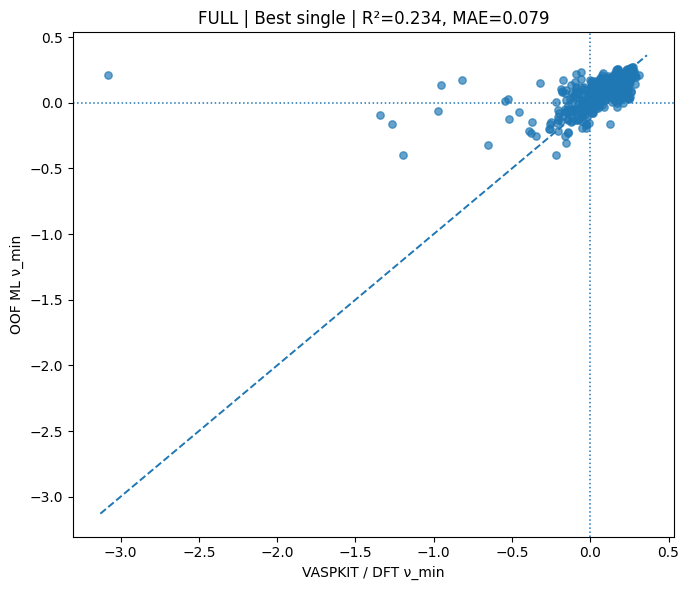

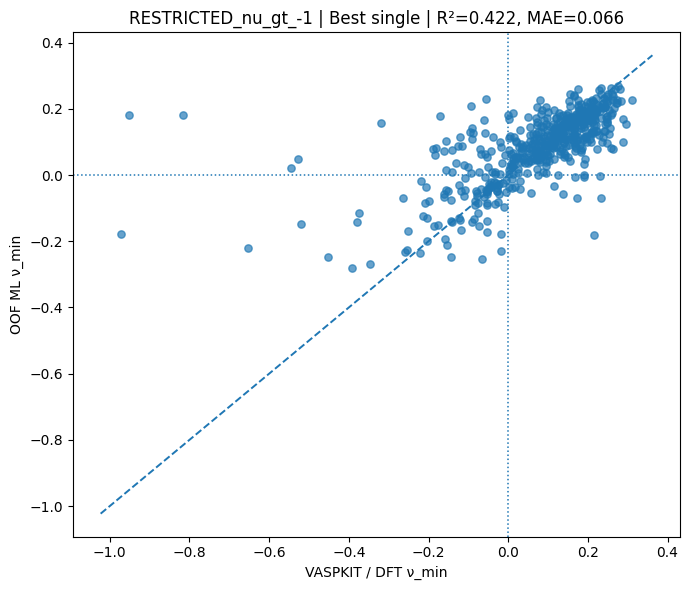

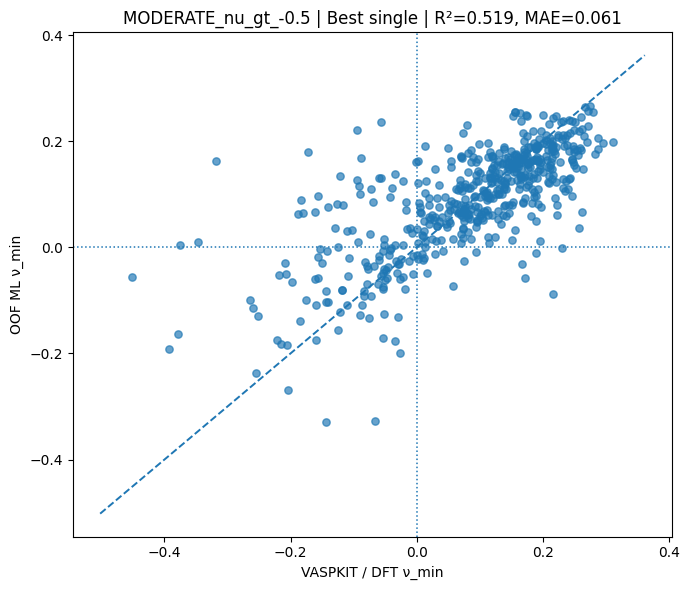

In [61]:
for scenario in ["FULL","RESTRICTED_nu_gt_-1","MODERATE_nu_gt_-0.5"]:
    mask=SCENARIOS[scenario]; yy=y[mask]; pp=ensemble_pred[(scenario,"Best single")]
    r2=r2_score(yy,pp); mae=mean_absolute_error(yy,pp)
    fig,ax=plt.subplots(figsize=(7,6))
    ax.scatter(yy,pp,alpha=0.68,s=28)
    lo=min(yy.min(),pp.min())-0.05; hi=max(yy.max(),pp.max())+0.05
    ax.plot([lo,hi],[lo,hi],'--',linewidth=1.4)
    ax.axvline(0,linestyle=':',linewidth=1.1); ax.axhline(0,linestyle=':',linewidth=1.1)
    ax.set_xlabel("VASPKIT / DFT ν_min")
    ax.set_ylabel("OOF ML ν_min")
    ax.set_title(f"{scenario} | {ensemble_rows[0]['Model'] if False else 'Best single'} | R²={r2:.3f}, MAE={mae:.3f}")
    fig.tight_layout()
    fn=f"v5_parity_{scenario}.png"
    fig.savefig(os.path.join(OUT_DIR,fn),dpi=240)
    plt.show()

## 17. آیا به R² > 0.98 رسیدیم؟

این سلول فقط وضعیت واقعی را گزارش می‌کند. هیچ مدلی به صورت مصنوعی برای عبور از آستانه تنظیم نشده است.

In [62]:
core_best = comparison_table.sort_values("R2",ascending=False).iloc[0]
print("="*90)
print("MAX AUXETIC ML V5 — SUMMARY")
print("="*90)
print("Dataset FULL:", len(df))
print("Features:", X_rich.shape[1])
print("Auxetic FULL:", int((y<0).sum()), f"({100*(y<0).mean():.2f}%)")
print("Best scenario:", core_best["Scenario"])
print("Best evaluation:", core_best["Model"])
print("Best R²:", float(core_best["R2"]))
print("Best MAE:", float(core_best["MAE"]))
print("Best RMSE:", float(core_best["RMSE"]))
print("R² > 0.98:", "YES" if core_best["R2"]>0.98 else "NO")
print("\nScientific note:")
print("Restricted models are domain-limited sensitivity analyses, not replacements for FULL-data validation.")
print("Severe negative ν values must first pass tensor-vs-VASPKIT validation before being treated as artifacts.")
print("="*90)

MAX AUXETIC ML V5 — SUMMARY
Dataset FULL: 547
Features: 186
Auxetic FULL: 134 (24.50%)
Best scenario: MODERATE_nu_gt_-0.5
Best evaluation: Best single
Best R²: 0.5191416218275198
Best MAE: 0.06094938233344437
Best RMSE: 0.09020772861914038
R² > 0.98: NO

Scientific note:
Restricted models are domain-limited sensitivity analyses, not replacements for FULL-data validation.
Severe negative ν values must first pass tensor-vs-VASPKIT validation before being treated as artifacts.


## 18. خروجی نهایی برای مقاله

فایل‌های کلیدی:

- `v5_scenario_summary.csv`
- `v5_baseline_scenarios.csv`
- `v5_core_comparison.csv`
- `v5_groupkfold.csv`
- `v5_tensor_vs_vaspkit_validation.csv`
- `v5_error_analysis.csv`
- `v5_parity_*.png`

### معیار انتشار
نتیجهٔ «دقت بسیار بالا» فقط زمانی قابل اتکا است که بهبود همزمان در OOF، Restricted، و GroupKFold مشاهده شود و مقادیر شدید با reconstruction مستقل سازگار باشند.